In [ ]:
# ============================================================
# STEP 1: INSTALL REQUIRED PACKAGES
# ============================================================

!pip install torch_geometric -q
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-2.2.0+cu121.html -q
!pip install sentence-transformers umap-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 21.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 62.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 946.2/946.2 kB 22.8 MB/s eta 0:00:00


In [ ]:
# ============================================================
# STEP 2: IMPORTS
# ============================================================

import os
import re
import random
import hashlib
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
from typing import Dict, List, Tuple, Optional
from itertools import combinations

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.distributions import Normal

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# PyTorch Geometric
from torch_geometric.nn import GATConv, global_mean_pool

# Sentence Transformers for embeddings
from sentence_transformers import SentenceTransformer

# Optional UMAP
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("⚠️ UMAP not available")



In [ ]:
# ============================================================
# STEP 3: DEVICE & REPRODUCIBILITY
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



Using device: cpu


In [ ]:
# ============================================================
# STEP 4: DRUG NAME UTILITIES
# ============================================================

def normalize_drug_name(name: str) -> str:
    """Normalize drug name by removing extra text and standardizing format"""
    if not isinstance(name, str):
        return ""
    name = name.lower().strip()
    name = re.sub(r"\([^)]*\)", "", name)
    name = re.sub(r"\s+brand:.*", "", name, flags=re.IGNORECASE)
    name = re.sub(r"\s*\+\s*", ", ", name)
    name = re.sub(r"\s*,\s*", ", ", name)
    name = re.sub(r"\s+", " ", name)
    return name.strip()

def sort_drug_combo(combo: str) -> str:
    """Sort drugs in a combination alphabetically"""
    if not isinstance(combo, str):
        return ""
    drugs = [d.strip() for d in combo.split(",") if d.strip()]
    drugs = sorted(drugs)
    return ", ".join(drugs)

def split_combo(combo: str) -> List[str]:
    """Split drug combination into individual drugs"""
    if not isinstance(combo, str):
        return []
    return [d.strip() for d in combo.split(",") if d.strip()]

def deduplicate_combo(combo: str) -> str:
    """Remove duplicate drugs from combination"""
    drugs = split_combo(combo)
    unique_drugs = sorted(set(drugs))
    return ", ".join(unique_drugs)



In [ ]:
# ============================================================
# STEP 5: DATA LOADING
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

file_path1 = '/content/drive/MyDrive/khezri/drug_data/merged_drug.xlsx'
file_path2 = '/content/drive/MyDrive/khezri/drug_data/drug_mechanism.xlsx'

clinic_df = pd.read_excel(file_path1, engine="openpyxl")
mech_df = pd.read_excel(file_path2, engine="openpyxl")

print(f"Loaded {len(clinic_df)} patients, {len(mech_df)} mechanism entries")

# Apply normalization
clinic_df["merged_drugs_norm"] = (
    clinic_df["merged_drugs"]
    .astype(str)
    .apply(normalize_drug_name)
    .apply(sort_drug_combo)
    .apply(deduplicate_combo)
)

mech_df["Drug Name Norm"] = (
    mech_df["Drug Name"]
    .astype(str)
    .apply(normalize_drug_name)
    .apply(sort_drug_combo)
    .apply(deduplicate_combo)
)

print(f"✅ Drug names normalized")
print(f"   Unique regimens: {clinic_df['merged_drugs_norm'].nunique()}")

# Create hba1c_category for visualization
def categorize_hba1c(val):
    if pd.isna(val):
        return 'Unknown'
    if val < 5.7:
        return 'Normal'
    elif val < 6.5:
        return 'Prediabetes'
    else:
        return 'Diabetes'

clinic_df['hba1c_category'] = clinic_df['hba1c'].apply(categorize_hba1c)
print(f"   hba1c categories: {clinic_df['hba1c_category'].unique()}")



Mounted at /content/drive
Loaded 4547 patients, 164 mechanism entries
✅ Drug names normalized
   Unique regimens: 1365
   hba1c categories: ['Diabetes' 'Prediabetes' 'Normal']


In [ ]:
# ============================================================
# STEP 6: CLINICAL FEATURE DEFINITION
# ============================================================

numeric_cols = ["fbs", "glu", "hba1c", "TG", "cho", "LDL", "HDL", "UA", "Na", "K", "Ca", "Vit D", "age"]
categorical_cols = ["sex", "fbs_category", "tg_category", "cho_category"]

# Drop missing values
clinic_df = clinic_df.dropna(subset=numeric_cols + categorical_cols).reset_index(drop=True)


# ============================================================
# STEP 7: LEAKAGE‑FREE SPLIT BY REGIMEN (GROUP‑BASED)
# ============================================================
from sklearn.model_selection import GroupShuffleSplit

# Groups = unique drug combination strings
groups = clinic_df["merged_drugs_norm"]

# First split: test set (20% of groups)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_val, idx_test = next(gss1.split(clinic_df, groups=groups))

# Second split: validation set (20% of remaining groups → 16% of patients)
groups_train_val = groups.iloc[idx_train_val]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_rel, idx_val_rel = next(gss2.split(clinic_df.iloc[idx_train_val], groups=groups_train_val))

# Convert indices
idx_train = idx_train_val[idx_train_rel]
idx_val = idx_train_val[idx_val_rel]
# idx_test remains as is

# Create dataframes
train_df = clinic_df.iloc[idx_train].copy()
val_df   = clinic_df.iloc[idx_val].copy()
test_df  = clinic_df.iloc[idx_test].copy()

print(f"Leakage‑free splits: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# Sanity check: no drug combination appears in both train and test
train_combos = set(clinic_df.iloc[idx_train]["merged_drugs_norm"])
test_combos  = set(clinic_df.iloc[idx_test]["merged_drugs_norm"])
assert len(train_combos & test_combos) == 0, "❌ Leakage detected!"
print("✅ Verified: train and test have no common regimens.")

# ============================================================
# STEP 8: DRUG VOCABULARY (TRAIN ONLY)
# ============================================================

def build_drug_vocabulary(train_df):
    """Build drug vocabulary from training data only"""
    all_drugs = set()
    for combo in train_df["merged_drugs_norm"]:
        for drug in split_combo(combo):
            all_drugs.add(drug)
    drug_to_idx = {drug: i for i, drug in enumerate(sorted(all_drugs))}
    idx_to_drug = {i: drug for drug, i in drug_to_idx.items()}
    return drug_to_idx, idx_to_drug, len(drug_to_idx)

def encode_regimen_multi_hot(combo, drug_to_idx):
    """Convert drug combination to multi-hot encoding"""
    vec = np.zeros(len(drug_to_idx), dtype=np.float32)
    for drug in split_combo(combo):
        if drug in drug_to_idx:
            vec[drug_to_idx[drug]] = 1.0
    return vec

def filter_to_train_vocab(combo, drug_to_idx):
    """Filter out drugs not in training vocabulary"""
    if not isinstance(combo, str):
        return ""
    drugs = [d.strip() for d in combo.split(",") if d.strip()]
    filtered = [d for d in drugs if d in drug_to_idx]
    return ", ".join(sorted(filtered))

# Build vocabulary
drug_to_idx, idx_to_drug, num_drugs = build_drug_vocabulary(train_df)
drug_vocab = list(drug_to_idx.keys())
print(f"Drug vocabulary size: {num_drugs}")

# Filter validation and test sets
val_df["merged_drugs_norm"] = val_df["merged_drugs_norm"].apply(lambda x: filter_to_train_vocab(x, drug_to_idx))
test_df["merged_drugs_norm"] = test_df["merged_drugs_norm"].apply(lambda x: filter_to_train_vocab(x, drug_to_idx))

# ============================================================
# STEP 9: CLINICAL PREPROCESSING
# ============================================================

scaler = StandardScaler()
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_num = scaler.fit_transform(clinic_df[numeric_cols])
X_cat = ohe.fit_transform(clinic_df[categorical_cols])
X_all = np.hstack([X_num, X_cat]).astype(np.float32)

clinical_dim = X_all.shape[1]
print(f"Clinical feature dimension: {clinical_dim}")

# Split features
X_train = X_all[idx_train]
X_val = X_all[idx_val]
X_test = X_all[idx_test]



Splits: Train=3182, Val=455, Test=910
Drug vocabulary size: 160
Clinical feature dimension: 25


In [ ]:
# ============================================================
# STEP 10: MECHANISM EMBEDDINGS (Semantic)
# ============================================================

def build_mechanism_embeddings(drug_to_idx, mech_df, embed_dim=128):
    """Build semantic mechanism embeddings using SentenceTransformer"""
    print("\n" + "="*70)
    print("🔬 BUILDING MECHANISM EMBEDDINGS")
    print("="*70)

    # Prepare mechanism text
    mech_df = mech_df.copy()
    mech_df["Drug Name Norm"] = mech_df["Drug Name"].astype(str).apply(normalize_drug_name).apply(sort_drug_combo)

    text_cols = ["Mechanisms", "Description", "Target IDs", "Pathway IDs", "ATC Code(s)"]

    def get_mech_text(row):
        parts = []
        for c in text_cols:
            if c in row and pd.notna(row[c]):
                parts.append(str(row[c]))
        return " | ".join(parts) if parts else row["Drug Name Norm"]

    mech_df["mech_text"] = mech_df.apply(get_mech_text, axis=1)

    # Encode
    model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
    actual_dim = model.get_sentence_embedding_dimension()
    print(f"   Semantic model dimension: {actual_dim}")

    # Project if needed
    proj = None
    if actual_dim != embed_dim:
        proj = nn.Linear(actual_dim, embed_dim).to(device)

    drug_embeddings = {}
    missing = []

    with torch.no_grad():
        for drug in tqdm(drug_to_idx.keys(), desc="Embedding drugs"):
            rows = mech_df[mech_df["Drug Name Norm"] == drug]
            if len(rows) == 0:
                drug_embeddings[drug] = torch.zeros(embed_dim)
                missing.append(drug)
                continue
            text = rows["mech_text"].iloc[0]
            e = model.encode(text, convert_to_tensor=True)
            if proj is not None:
                e = proj(e)
            e = F.normalize(e, dim=0)
            drug_embeddings[drug] = e.cpu()

    if missing:
        print(f"   ⚠️ No mechanism data for {len(missing)} drugs")

    print(f"✅ Built embeddings for {len(drug_embeddings)} drugs (dim={embed_dim})")
    return drug_embeddings, embed_dim

drug_embeddings, embed_dim = build_mechanism_embeddings(drug_to_idx, mech_df, embed_dim=128)




🔬 BUILDING MECHANISM EMBEDDINGS


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   Semantic model dimension: 384


Embedding drugs: 100%|██████████| 160/160 [00:07<00:00, 22.04it/s]

   ⚠️ No mechanism data for 55 drugs
✅ Built embeddings for 160 drugs (dim=128)


In [ ]:
# ============================================================
# STEP 11: BUILD DRUG SIMILARITY GRAPH (Multi-View)
# ============================================================

def build_drug_graph(drug_to_idx, mech_df, drug_embeddings, cos_thresh=0.7):
    """Build multi-view drug similarity graph"""
    print("\n" + "="*70)
    print("📊 BUILDING DRUG SIMILARITY GRAPH")
    print("="*70)

    n = len(drug_to_idx)
    drugs = list(drug_to_idx.keys())

    # Cosine similarity from embeddings
    emb_mat = torch.stack([drug_embeddings[d] for d in drugs], dim=0)
    emb_norm = F.normalize(emb_mat, dim=1)
    sim = emb_norm @ emb_norm.t()

    edges = set()

    # Add edges based on cosine similarity
    for i in range(n):
        for j in range(i+1, n):
            if sim[i, j].item() >= cos_thresh:
                edges.add((i, j))
                edges.add((j, i))

    # Add edges from shared ATC codes
    mech_df = mech_df.copy()
    mech_df["Drug Name Norm"] = mech_df["Drug Name"].astype(str).apply(normalize_drug_name).apply(sort_drug_combo)

    atc_map = {}
    target_map = {}

    for _, row in mech_df.iterrows():
        dname = row["Drug Name Norm"]
        if dname not in drug_to_idx:
            continue
        idx = drug_to_idx[dname]
        atc = str(row.get("ATC Code(s)", "")).split(";")
        targets = str(row.get("Target IDs", "")).split(";")

        for a in atc:
            a = a.strip()
            if a:
                atc_map.setdefault(a, []).append(idx)
        for t in targets:
            t = t.strip()
            if t:
                target_map.setdefault(t, []).append(idx)

    def add_edges_from_map(m):
        for lst in m.values():
            for i in lst:
                for j in lst:
                    if i != j:
                        edges.add((i, j))
                        edges.add((j, i))

    add_edges_from_map(atc_map)
    add_edges_from_map(target_map)

    # Add self-loops
    for i in range(n):
        edges.add((i, i))

    edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous()
    print(f"   Created graph with {n} nodes and {edge_index.shape[1]} edges")
    print(f"   Average degree: {edge_index.shape[1] / n:.2f}")

    return edge_index

drug_edge_index = build_drug_graph(drug_to_idx, mech_df, drug_embeddings, cos_thresh=0.7)




📊 BUILDING DRUG SIMILARITY GRAPH
   Created graph with 160 nodes and 5214 edges
   Average degree: 32.59


In [ ]:
# ============================================================
# STEP 12: DATASET CLASS
# ============================================================

class MAPCTv13Dataset(Dataset):
    """Dataset for MAPCT-v13"""

    def __init__(self, df, clinical_features, drug_to_idx):
        self.df = df.reset_index(drop=True)
        self.clinical_features = clinical_features.astype(np.float32)
        self.drug_to_idx = drug_to_idx

        # Precompute labels
        self.labels = []
        for _, row in self.df.iterrows():
            label = encode_regimen_multi_hot(row["merged_drugs_norm"], drug_to_idx)
            self.labels.append(label)
        self.labels = np.stack(self.labels).astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return {
            "clinical": torch.from_numpy(self.clinical_features[idx]),
            "label": torch.from_numpy(self.labels[idx]),
            "index": idx,
            "combo": self.df.iloc[idx]["merged_drugs_norm"]  # Store combo string
        }

# Create datasets
train_dataset = MAPCTv13Dataset(train_df, X_train, drug_to_idx)
val_dataset = MAPCTv13Dataset(val_df, X_val, drug_to_idx)
test_dataset = MAPCTv13Dataset(test_df, X_test, drug_to_idx)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")



Train batches: 50, Val batches: 8, Test batches: 15


In [ ]:
# ============================================================
# STEP 13: GNN ENCODER FOR DRUGS
# ============================================================

class DrugGNNEncoder(nn.Module):
    """GNN for encoding drug mechanisms with graph attention"""

    def __init__(self, embed_dim=128, hidden_dim=128, out_dim=128):
        super().__init__()
        self.conv1 = GATConv(embed_dim, hidden_dim, heads=2, concat=False)
        self.conv2 = GATConv(hidden_dim, hidden_dim, heads=2, concat=False)
        self.lin_out = nn.Linear(hidden_dim, out_dim)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x, edge_index):
        h = F.elu(self.conv1(x, edge_index))
        h = self.dropout(h)
        h = F.elu(self.conv2(h, edge_index))
        h = self.dropout(h)
        return self.lin_out(h)

# ============================================================
# STEP 14: REGIMEN ENCODER (GNN + Attention)
# ============================================================

class RegimenEncoder(nn.Module):
    """Encode drug regimens using GNN and self-attention"""

    def __init__(self, drug_to_idx, drug_embeddings, drug_gnn, latent_dim=128, n_heads=4):
        super().__init__()
        self.drug_to_idx = drug_to_idx
        self.idx_to_drug = {i: d for d, i in drug_to_idx.items()}
        self.drug_gnn = drug_gnn

        # Static drug embeddings (will be updated by GNN)
        emb_mat = torch.stack([drug_embeddings[d] for d in self.idx_to_drug.values()], dim=0)
        self.register_buffer("drug_emb_init", emb_mat)

        self.attn = nn.MultiheadAttention(embed_dim=latent_dim, num_heads=n_heads, batch_first=True)
        self.lin_proj = nn.Linear(latent_dim, latent_dim)

    def forward(self, combos, edge_index):
        # Get GNN-enhanced embeddings
        x = self.drug_emb_init.to(edge_index.device)
        x = self.drug_gnn(x, edge_index)

        # Build sequence for each regimen
        batch_tensors = []
        max_len = 0
        idx_lists = []

        for combo in combos:
            idxs = [self.drug_to_idx[d] for d in split_combo(combo) if d in self.drug_to_idx]
            if len(idxs) == 0:
                idxs = [0]
            idx_lists.append(idxs)
            max_len = max(max_len, len(idxs))

        # Pad sequences
        for idxs in idx_lists:
            pad = idxs + [idxs[-1]] * (max_len - len(idxs))
            emb_seq = x[torch.tensor(pad, dtype=torch.long, device=x.device)]
            batch_tensors.append(emb_seq)

        # Self-attention over drug sequence
        batch_seq = torch.stack(batch_tensors, dim=0)
        attn_out, _ = self.attn(batch_seq, batch_seq, batch_seq)
        pooled = attn_out.mean(dim=1)
        z = self.lin_proj(pooled)
        return F.normalize(z, dim=1)



In [ ]:
# ============================================================
# STEP 15: CONDITIONAL NORMALIZING FLOW
# ============================================================

class ConditionalRealNVPLayer(nn.Module):
    """Real NVP coupling layer conditioned on clinical latent"""

    def __init__(self, dim, cond_dim, hidden_dim=256, flip=False):
        super().__init__()
        assert dim % 2 == 0
        self.dim = dim
        self.cond_dim = cond_dim
        self.flip = flip
        self.split_dim = dim // 2

        self.scale_net = nn.Sequential(
            nn.Linear(self.split_dim + cond_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, self.split_dim),
            nn.Tanh()
        )
        self.trans_net = nn.Sequential(
            nn.Linear(self.split_dim + cond_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, self.split_dim)
        )

    def forward(self, x, cond, reverse=False):
        if self.flip:
            x1, x2 = x[:, self.split_dim:], x[:, :self.split_dim]
        else:
            x1, x2 = x[:, :self.split_dim], x[:, self.split_dim:]

        h = torch.cat([x1, cond], dim=1)
        s = self.scale_net(h)
        t = self.trans_net(h)
        s = torch.clamp(s, -5.0, 5.0)

        if not reverse:
            y2 = x2 * torch.exp(s) + t
            log_det = s.sum(dim=1)
        else:
            y2 = (x2 - t) * torch.exp(-s)
            log_det = -s.sum(dim=1)

        if self.flip:
            y = torch.cat([y2, x1], dim=1)
        else:
            y = torch.cat([x1, y2], dim=1)

        return y, log_det

class ConditionalFlow(nn.Module):
    """Conditional Normalizing Flow for flexible latent distribution"""

    def __init__(self, latent_dim=128, cond_dim=128, num_layers=6, hidden_dim=256):
        super().__init__()
        self.latent_dim = latent_dim
        self.cond_dim = cond_dim

        layers = []
        for i in range(num_layers):
            layers.append(
                ConditionalRealNVPLayer(latent_dim, cond_dim, hidden_dim, flip=(i % 2 == 1))
            )
        self.flow_layers = nn.ModuleList(layers)

        self.register_buffer("base_mean", torch.zeros(latent_dim))
        self.register_buffer("base_std", torch.ones(latent_dim))

    @property
    def base_dist(self):
        return Normal(self.base_mean, self.base_std)

    def forward(self, z, cond, reverse=False):
        log_det_total = torch.zeros(z.size(0), device=z.device)
        x = z

        if not reverse:
            for layer in self.flow_layers:
                x, log_det = layer(x, cond, reverse=False)
                log_det_total += log_det
        else:
            for layer in reversed(self.flow_layers):
                x, log_det = layer(x, cond, reverse=True)
                log_det_total += log_det

        return x, log_det_total

    def log_prob(self, x, cond):
        z, log_det = self.forward(x, cond, reverse=True)
        log_prob_base = self.base_dist.log_prob(z).sum(dim=1)
        return log_prob_base + log_det

    def sample(self, cond, num_samples=1):
        B = cond.size(0)
        z = self.base_dist.sample((B * num_samples,))
        cond_rep = cond.unsqueeze(1).expand(-1, num_samples, -1).reshape(B * num_samples, -1)
        x, _ = self.forward(z, cond_rep, reverse=False)
        return x.reshape(B, num_samples, -1)



In [ ]:


# ============================================================
# STEP 16: CLINICAL ENCODER
# ============================================================

class ClinicalMLPEncoder(nn.Module):
    """Encode clinical features into latent space"""

    def __init__(self, input_dim, hidden_dim=128, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=1)

# ============================================================
# STEP 17: DRUG DECODER
# ============================================================

class DrugDecoder(nn.Module):
    """Decode latent representations to drug predictions"""

    def __init__(self, latent_dim=128, num_drugs=None, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, num_drugs)
        )

    def forward(self, z):
        return self.net(z)

# ============================================================
# STEP 18: CONTRASTIVE LOSS FUNCTIONS
# ============================================================

def info_nce(z1, z2, temperature=0.07):
    """InfoNCE contrastive loss for alignment"""
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits = z1 @ z2.t() / temperature
    labels = torch.arange(z1.size(0), device=z1.device)
    loss_fwd = F.cross_entropy(logits, labels)
    loss_rev = F.cross_entropy(logits.t(), labels)
    return 0.5 * (loss_fwd + loss_rev)

# ============================================================
# STEP 19: FULL MAPCT-v13 MODEL
# ============================================================

class MAPCTv13(nn.Module):
    """
    MAPCT-v13: Hybrid Flow + GNN + Contrastive Tri-Training

    Key innovations:
    1. Conditional Normalizing Flow for flexible regimen distribution
    2. GNN for drug-drug interaction modeling
    3. Tri-training contrastive losses (C-R, C-F, R-F)
    4. Semantic mechanism embeddings
    """

    def __init__(self, clinical_dim, drug_to_idx, drug_embeddings, drug_edge_index,
                 clinical_df, latent_dim=128):
        super().__init__()
        self.clinical_dim = clinical_dim
        self.drug_to_idx = drug_to_idx
        self.idx_to_drug = {i: d for d, i in drug_to_idx.items()}
        self.drug_edge_index = drug_edge_index
        self.clinical_df = clinical_df
        self.latent_dim = latent_dim

        # Core components
        self.clinical_encoder = ClinicalMLPEncoder(clinical_dim, hidden_dim=128, latent_dim=latent_dim)
        self.drug_gnn = DrugGNNEncoder(embed_dim=128, hidden_dim=128, out_dim=latent_dim)
        self.regimen_encoder = RegimenEncoder(drug_to_idx, drug_embeddings, self.drug_gnn,
                                              latent_dim=latent_dim, n_heads=4)
        self.flow = ConditionalFlow(latent_dim=latent_dim, cond_dim=latent_dim,
                                    num_layers=6, hidden_dim=256)
        self.drug_decoder = DrugDecoder(latent_dim, num_drugs=len(drug_to_idx), hidden_dim=256)

    def forward_encoders(self, batch):
        """Encode clinical and regimen spaces"""
        clinical = batch["clinical"].to(self.drug_edge_index.device)
        z_clin = self.clinical_encoder(clinical)

        # Get combos from batch
        combos = batch["combo"]
        z_reg = self.regimen_encoder(combos, self.drug_edge_index)

        return z_clin, z_reg

    def forward(self, batch):
        """Full forward pass"""
        z_clin, z_reg = self.forward_encoders(batch)

        # Sample from flow
        z_flow_samples = self.flow.sample(z_clin, num_samples=1)[:, 0, :]
        logits = self.drug_decoder(z_flow_samples)

        return logits, z_clin, z_reg, z_flow_samples

    def get_drug_embeddings(self):
        """Get GNN-enhanced drug embeddings"""
        x = self.regimen_encoder.drug_emb_init.to(self.drug_edge_index.device)
        return self.drug_gnn(x, self.drug_edge_index)

# ============================================================
# STEP 20: TRAINER CLASS
# ============================================================

class MAPCTv13Trainer:
    """Trainer for MAPCT-v13 with tri-training contrastive losses"""

    def __init__(self, model, device, train_loader, val_loader,
                 lr=1e-3, flow_lr=1e-4,
                 lambda_drug=1.0, lambda_flow=0.1,
                 alpha_CR=0.3, alpha_CF=0.3, alpha_RF=0.3):

        self.model = model.to(device)
        self.device = device
        self.train_loader = train_loader
        self.val_loader = val_loader

        self.lambda_drug = lambda_drug
        self.lambda_flow = lambda_flow
        self.alpha_CR = alpha_CR
        self.alpha_CF = alpha_CF
        self.alpha_RF = alpha_RF

        # Separate optimizers for flow and main parameters
        main_params = (list(self.model.clinical_encoder.parameters()) +
                       list(self.model.regimen_encoder.parameters()) +
                       list(self.model.drug_decoder.parameters()))
        flow_params = list(self.model.flow.parameters())

        self.opt_main = torch.optim.AdamW(main_params, lr=lr, weight_decay=1e-5)
        self.opt_flow = torch.optim.AdamW(flow_params, lr=flow_lr, weight_decay=1e-5)

        self.sched_main = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.opt_main, mode='min', patience=5, factor=0.5)
        self.sched_flow = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.opt_flow, mode='min', patience=5, factor=0.5)

        self.history = {
            'train_loss': [], 'val_loss': [], 'val_f1': [],
            'train_drug_loss': [], 'train_flow_loss': [],
            'train_contrast_CR': [], 'train_contrast_CF': [], 'train_contrast_RF': [],
            'lr_main': [], 'lr_flow': [], 'alignment': []
        }

    def train_epoch(self):
        """Train for one epoch"""
        self.model.train()

        epoch_metrics = {
            'loss': 0, 'drug_loss': 0, 'flow_loss': 0,
            'contrast_CR': 0, 'contrast_CF': 0, 'contrast_RF': 0
        }

        for batch in tqdm(self.train_loader, desc="Training"):
            labels = batch["label"].to(self.device)
            z_clin, z_reg = self.model.forward_encoders(batch)

            # Flow loss (negative log-likelihood)
            log_prob = self.model.flow.log_prob(z_reg, z_clin)
            loss_flow = -log_prob.mean()

            # Drug prediction loss
            z_flow_samples = self.model.flow.sample(z_clin, num_samples=1)[:, 0, :]
            logits = self.model.drug_decoder(z_flow_samples)
            loss_drug = F.binary_cross_entropy_with_logits(logits, labels)

            # Tri-training contrastive losses
            loss_CR = info_nce(z_clin, z_reg)      # Clinical vs Regimen
            loss_CF = info_nce(z_clin, z_flow_samples)  # Clinical vs Flow
            loss_RF = info_nce(z_reg, z_flow_samples)   # Regimen vs Flow

            # Combined loss
            loss = (self.lambda_drug * loss_drug +
                    self.lambda_flow * loss_flow +
                    self.alpha_CR * loss_CR +
                    self.alpha_CF * loss_CF +
                    self.alpha_RF * loss_RF)

            # Backward pass
            self.opt_main.zero_grad()
            self.opt_flow.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.opt_main.step()
            self.opt_flow.step()

            # Track metrics
            epoch_metrics['loss'] += loss.item()
            epoch_metrics['drug_loss'] += loss_drug.item()
            epoch_metrics['flow_loss'] += loss_flow.item()
            epoch_metrics['contrast_CR'] += loss_CR.item()
            epoch_metrics['contrast_CF'] += loss_CF.item()
            epoch_metrics['contrast_RF'] += loss_RF.item()

        n_batches = len(self.train_loader)
        return {k: v / n_batches for k, v in epoch_metrics.items()}

    def validate(self):
        """Validate the model"""
        self.model.eval()

        total_loss = 0
        all_preds = []
        all_labels = []
        all_alignments = []

        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc="Validation"):
                labels = batch["label"].to(self.device)
                z_clin, z_reg = self.model.forward_encoders(batch)

                # Alignment score
                alignment = F.cosine_similarity(z_clin, z_reg).mean().item()
                all_alignments.append(alignment)

                # Flow loss
                log_prob = self.model.flow.log_prob(z_reg, z_clin)
                loss_flow = -log_prob.mean()

                # Drug prediction
                z_flow = self.model.flow.sample(z_clin, num_samples=1)[:, 0, :]
                logits = self.model.drug_decoder(z_flow)
                loss_drug = F.binary_cross_entropy_with_logits(logits, labels)

                # Contrastive loss
                loss_CR = info_nce(z_clin, z_reg)
                loss = (self.lambda_drug * loss_drug +
                        self.lambda_flow * loss_flow +
                        self.alpha_CR * loss_CR)
                total_loss += loss.item()

                # Predictions
                probs = torch.sigmoid(logits).cpu().numpy()
                preds = (probs > 0.3).astype(int)
                all_preds.extend(preds)
                all_labels.extend(labels.cpu().numpy())

        val_f1 = f1_score(np.array(all_labels), np.array(all_preds),
                          average='micro', zero_division=0)
        mean_alignment = np.mean(all_alignments)

        return total_loss / len(self.val_loader), val_f1, mean_alignment

    def train(self, epochs=50, patience=10):
        """Main training loop"""
        best_val_f1 = 0
        patience_counter = 0

        for epoch in range(epochs):
            train_metrics = self.train_epoch()
            val_loss, val_f1, alignment = self.validate()

            # Store history
            self.history['train_loss'].append(train_metrics['loss'])
            self.history['val_loss'].append(val_loss)
            self.history['val_f1'].append(val_f1)
            self.history['alignment'].append(alignment)
            self.history['train_drug_loss'].append(train_metrics['drug_loss'])
            self.history['train_flow_loss'].append(train_metrics['flow_loss'])
            self.history['train_contrast_CR'].append(train_metrics['contrast_CR'])
            self.history['train_contrast_CF'].append(train_metrics['contrast_CF'])
            self.history['train_contrast_RF'].append(train_metrics['contrast_RF'])
            self.history['lr_main'].append(self.opt_main.param_groups[0]['lr'])
            self.history['lr_flow'].append(self.opt_flow.param_groups[0]['lr'])

            # Update learning rates
            self.sched_main.step(val_loss)
            self.sched_flow.step(val_loss)

            # Print progress
            if (epoch + 1) % 5 == 0:
                print(f"\nEpoch {epoch+1:3d}/{epochs}")
                print(f"  Train Loss: {train_metrics['loss']:.4f} | Drug: {train_metrics['drug_loss']:.4f} | Flow: {train_metrics['flow_loss']:.4f}")
                print(f"  Contrast: CR={train_metrics['contrast_CR']:.4f} CF={train_metrics['contrast_CF']:.4f} RF={train_metrics['contrast_RF']:.4f}")
                print(f"  Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f} | Alignment: {alignment:.4f}")

            # Early stopping
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                patience_counter = 0
                torch.save(self.model.state_dict(), 'best_mapct_v13.pt')
                print(f"  -> Best model saved (F1={val_f1:.4f})")
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"\nEarly stopping at epoch {epoch+1}")
                    break

        return self.history

# ============================================================
# STEP 21: EVALUATION AND VISUALIZATION FUNCTIONS
# ============================================================

def visualize_training_history(history):
    """Plot comprehensive training history"""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Loss curves
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # F1 Score
    axes[0, 1].plot(epochs, history['val_f1'], 'g-', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('F1 Score')
    axes[0, 1].set_title('Validation F1 Score')
    axes[0, 1].grid(True, alpha=0.3)

    # Alignment
    axes[0, 2].plot(epochs, history['alignment'], 'purple', linewidth=2)
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Cosine Similarity')
    axes[0, 2].set_title('Clinical-Regimen Alignment')
    axes[0, 2].axhline(0.5, color='green', linestyle='--', alpha=0.5)
    axes[0, 2].grid(True, alpha=0.3)

    # Component losses
    axes[1, 0].plot(epochs, history['train_drug_loss'], 'r-', label='Drug Loss')
    axes[1, 0].plot(epochs, history['train_flow_loss'], 'c-', label='Flow Loss')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].set_title('Component Losses')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Contrastive losses
    axes[1, 1].plot(epochs, history['train_contrast_CR'], 'b-', label='C-R')
    axes[1, 1].plot(epochs, history['train_contrast_CF'], 'g-', label='C-F')
    axes[1, 1].plot(epochs, history['train_contrast_RF'], 'r-', label='R-F')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].set_title('Contrastive Losses (Tri-training)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # Learning rates
    axes[1, 2].plot(epochs, history['lr_main'], 'b-', label='Main LR')
    axes[1, 2].plot(epochs, history['lr_flow'], 'r-', label='Flow LR')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Learning Rate')
    axes[1, 2].set_title('Learning Rate Schedule')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

    plt.suptitle('MAPCT-v13 Training History', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('v13_training_history.png', dpi=150)
    plt.show()
    print("✅ Training history saved as 'v13_training_history.png'")

def compute_complete_metrics(model, test_loader, device, threshold=0.3, num_stochastic=5):
    """Compute all metrics: prediction, alignment, diversity"""
    print("\n" + "="*60)
    print("📊 COMPLETE METRICS FOR MAPCT-v13")
    print("="*60)

    model.eval()
    all_preds = []
    all_labels = []
    align_scores = []
    all_diversity_sets = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            labels = batch["label"].to(device)
            z_clin, z_reg = model.forward_encoders(batch)

            # Alignment
            cos_sim = F.cosine_similarity(z_clin, z_reg).cpu().numpy()
            align_scores.extend(cos_sim)

            # Drug predictions
            z_flow = model.flow.sample(z_clin, num_samples=1)[:, 0, :]
            logits = model.drug_decoder(z_flow)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(int)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

            # Diversity (stochastic sampling)
            z_flow_multi = model.flow.sample(z_clin, num_samples=num_stochastic)
            for b in range(z_flow_multi.size(0)):
                patient_sets = []
                for s in range(num_stochastic):
                    logits_s = model.drug_decoder(z_flow_multi[b, s:s+1, :])
                    probs_s = torch.sigmoid(logits_s).cpu().numpy()[0]
                    drugs_k = set(np.where(probs_s > threshold)[0])
                    patient_sets.append(drugs_k)
                all_diversity_sets.append(patient_sets)

    # Metrics computation
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)

    results = {
        'precision': float(precision_score(y_true, y_pred, average='micro', zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, average='micro', zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, average='micro', zero_division=0)),
        'accuracy': float(accuracy_score(y_true.flatten(), y_pred.flatten())),
        'alignment': float(np.mean(align_scores)),
        'alignment_std': float(np.std(align_scores))
    }

    # Diversity
    all_jaccard_dists = []
    for patient_sets in all_diversity_sets:
        if len(patient_sets) < 2:
            continue
        for set1, set2 in combinations(patient_sets, 2):
            if len(set1 | set2) == 0:
                dist = 0.0
            else:
                jaccard = len(set1 & set2) / len(set1 | set2)
                dist = 1 - jaccard
            all_jaccard_dists.append(dist)
    results['diversity'] = float(np.mean(all_jaccard_dists)) if all_jaccard_dists else 0.0

    # Print report
    print(f"\n🎯 Drug Prediction (threshold={threshold}):")
    print(f"   Precision: {results['precision']:.4f}")
    print(f"   Recall:    {results['recall']:.4f}")
    print(f"   F1-Score:  {results['f1']:.4f}")
    print(f"   Accuracy:  {results['accuracy']:.4f}")
    print(f"\n🔗 Clinical–Regimen Alignment:")
    print(f"   Mean cosine: {results['alignment']:.4f} ± {results['alignment_std']:.4f}")
    print(f"\n🎨 Generation Diversity:")
    print(f"   Mean Jaccard distance: {results['diversity']:.4f}")

    return results

def visualize_latent_spaces_v13(model, test_loader, test_df, device):
    """PCA and t-SNE visualization of clinical and regimen latent spaces"""
    print("\n" + "="*60)
    print("🎨 LATENT SPACE VISUALIZATION")
    print("="*60)

    model.eval()
    z_clin_list = []
    z_reg_list = []
    hba1c_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Collecting latents"):
            clinical = batch["clinical"].to(device)
            z_clin = model.clinical_encoder(clinical)
            z_clin_list.append(z_clin.cpu().numpy())

            # Get regimen latents
            combos = batch["combo"]
            z_reg = model.regimen_encoder(combos, model.drug_edge_index)
            z_reg_list.append(z_reg.cpu().numpy())

            # Get hba1c labels
            for idx in batch["index"]:
                hba1c_labels.append(test_df.iloc[idx.item()]['hba1c_category'])

    Z_clin = np.vstack(z_clin_list)
    Z_reg = np.vstack(z_reg_list)
    hba1c_labels = np.array(hba1c_labels)

    # PCA
    pca = PCA(n_components=2, random_state=SEED)
    Z_clin_pca = pca.fit_transform(Z_clin)
    Z_reg_pca = pca.fit_transform(Z_reg)

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    unique_cats = np.unique(hba1c_labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))

    for cat, color in zip(unique_cats, colors):
        mask = hba1c_labels == cat
        axes[0, 0].scatter(Z_clin_pca[mask, 0], Z_clin_pca[mask, 1],
                          label=cat, alpha=0.6, s=20, color=color)
    axes[0, 0].set_title('Clinical Latent Space (PCA)')
    axes[0, 0].set_xlabel('PC1')
    axes[0, 0].set_ylabel('PC2')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].scatter(Z_reg_pca[:, 0], Z_reg_pca[:, 1], alpha=0.6, s=20, c='steelblue')
    axes[0, 1].set_title('Regimen Latent Space (PCA)')
    axes[0, 1].set_xlabel('PC1')
    axes[0, 1].set_ylabel('PC2')
    axes[0, 1].grid(True, alpha=0.3)

    # t-SNE
    print("Computing t-SNE...")
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
    Z_clin_tsne = tsne.fit_transform(Z_clin)

    for cat, color in zip(unique_cats, colors):
        mask = hba1c_labels == cat
        axes[1, 0].scatter(Z_clin_tsne[mask, 0], Z_clin_tsne[mask, 1],
                          label=cat, alpha=0.6, s=20, color=color)
    axes[1, 0].set_title('Clinical Latent Space (t-SNE)')
    axes[1, 0].set_xlabel('t-SNE 1')
    axes[1, 0].set_ylabel('t-SNE 2')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    Z_reg_tsne = tsne.fit_transform(Z_reg)
    axes[1, 1].scatter(Z_reg_tsne[:, 0], Z_reg_tsne[:, 1], alpha=0.6, s=20, c='steelblue')
    axes[1, 1].set_title('Regimen Latent Space (t-SNE)')
    axes[1, 1].set_xlabel('t-SNE 1')
    axes[1, 1].set_ylabel('t-SNE 2')
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle('MAPCT-v13: Latent Space Visualization', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('v13_latent_spaces.png', dpi=150)
    plt.show()
    print("✅ Latent space plots saved as 'v13_latent_spaces.png'")

    return Z_clin, Z_reg

def visualize_alignment_v13(model, test_loader, device):
    """Visualize clinical-regimen alignment"""
    print("\n" + "="*60)
    print("🔗 CLINICAL-REGIMEN ALIGNMENT ANALYSIS")
    print("="*60)

    model.eval()
    alignments = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Computing alignment"):
            z_clin, z_reg = model.forward_encoders(batch)
            sim = F.cosine_similarity(z_clin, z_reg).cpu().numpy()
            alignments.extend(sim)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram
    axes[0].hist(alignments, bins=30, edgecolor='black', alpha=0.7)
    axes[0].axvline(np.mean(alignments), color='red', linestyle='--',
                   label=f'Mean: {np.mean(alignments):.3f}')
    axes[0].set_xlabel('Cosine Similarity')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Clinical-Regimen Alignment Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Box plot by percentile
    axes[1].boxplot(alignments)
    axes[1].set_ylabel('Cosine Similarity')
    axes[1].set_title('Alignment Distribution (Box Plot)')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('MAPCT-v13: Clinical-Regimen Alignment', fontsize=14)
    plt.tight_layout()
    plt.savefig('v13_alignment.png', dpi=150)
    plt.show()

    print(f"\n📊 Alignment Statistics:")
    print(f"   Mean: {np.mean(alignments):.4f}")
    print(f"   Std:  {np.std(alignments):.4f}")
    print(f"   Min:  {np.min(alignments):.4f}")
    print(f"   Max:  {np.max(alignments):.4f}")
    print(f"   Median: {np.median(alignments):.4f}")

    return alignments

def show_patient_analysis_v13(model, test_loader, test_df, idx_to_drug, device, threshold=0.3, num_patients=3):
    """Show detailed analysis for sample patients"""
    print("\n" + "="*60)
    print("👥 PATIENT-LEVEL ANALYSIS")
    print("="*60)

    model.eval()
    patients_shown = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            if patients_shown >= num_patients:
                break

            z_clin, z_reg = model.forward_encoders(batch)
            z_flow = model.flow.sample(z_clin, num_samples=1)[:, 0, :]
            logits = model.drug_decoder(z_flow)
            probs = torch.sigmoid(logits).cpu().numpy()

            for i in range(min(len(probs), num_patients - patients_shown)):
                idx = batch["index"][i].item()
                patient = test_df.iloc[idx]

                print(f"\n{'='*60}")
                print(f"PATIENT {patients_shown + 1} (Test index: {idx})")
                print(f"{'='*60}")

                # Clinical profile
                print(f"\n📊 CLINICAL PROFILE:")
                print(f"   Age: {patient.get('age', 'N/A')}")
                print(f"   Sex: {patient.get('sex', 'N/A')}")
                print(f"   HbA1c: {patient.get('hba1c', 'N/A')} ({patient.get('hba1c_category', 'N/A')})")

                # Actual regimen
                actual_combo = patient["merged_drugs_norm"]
                print(f"\n💊 ACTUAL REGIMEN: {actual_combo if actual_combo else 'None'}")

                # Predicted regimen
                pred_drugs = [(idx_to_drug[j], probs[i][j]) for j in range(len(probs[i]))
                             if probs[i][j] > threshold]
                pred_drugs.sort(key=lambda x: x[1], reverse=True)

                print(f"\n🤖 PREDICTED REGIMEN (threshold={threshold}):")
                if pred_drugs:
                    for drug, prob in pred_drugs[:10]:
                        print(f"   • {drug:<35} prob={prob:.4f}")
                else:
                    print("   No drugs predicted")

                # Alignment
                alignment = F.cosine_similarity(z_clin[i:i+1], z_reg[i:i+1]).item()
                print(f"\n🔗 CLINICAL-REGIMEN ALIGNMENT: {alignment:.4f}")

                patients_shown += 1


In [ ]:
# ============================================================
# ADD THIS UMAP VISUALIZATION FUNCTION
# ============================================================

def visualize_umap_latent_spaces_v13(model, test_loader, test_df, device, n_neighbors=15):
    """UMAP visualization of clinical and regimen latent spaces"""
    if not UMAP_AVAILABLE:
        print("⚠️ UMAP not installed. Install with: pip install umap-learn")
        return None, None

    print("\n" + "="*70)
    print("🎨 UMAP LATENT SPACE VISUALIZATION (v13)")
    print("="*70)

    model.eval()
    z_clin_list = []
    z_reg_list = []
    hba1c_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Collecting latents for UMAP"):
            clinical = batch["clinical"].to(device)
            z_clin = model.clinical_encoder(clinical)
            z_clin_list.append(z_clin.cpu().numpy())

            # Get regimen latents
            combos = batch["combo"]
            z_reg = model.regimen_encoder(combos, model.drug_edge_index)
            z_reg_list.append(z_reg.cpu().numpy())

            # Get hba1c labels
            for idx in batch["index"]:
                hba1c_labels.append(test_df.iloc[idx.item()]['hba1c_category'])

    Z_clin = np.vstack(z_clin_list)
    Z_reg = np.vstack(z_reg_list)
    hba1c_labels = np.array(hba1c_labels)

    # UMAP for clinical space
    print("Computing UMAP for clinical space...")
    reducer_clin = umap.UMAP(random_state=SEED, n_components=2, n_neighbors=n_neighbors)
    Z_clin_umap = reducer_clin.fit_transform(Z_clin)

    # UMAP for regimen space
    print("Computing UMAP for regimen space...")
    reducer_reg = umap.UMAP(random_state=SEED, n_components=2, n_neighbors=n_neighbors)
    Z_reg_umap = reducer_reg.fit_transform(Z_reg)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Clinical UMAP
    unique_cats = np.unique(hba1c_labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))

    for cat, color in zip(unique_cats, colors):
        mask = hba1c_labels == cat
        if mask.sum() > 0:
            axes[0].scatter(Z_clin_umap[mask, 0], Z_clin_umap[mask, 1],
                           label=cat, alpha=0.6, s=20, color=color)
    axes[0].set_title(f'Clinical Latent Space (UMAP, n_neighbors={n_neighbors})')
    axes[0].set_xlabel('UMAP Dimension 1')
    axes[0].set_ylabel('UMAP Dimension 2')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Regimen UMAP
    axes[1].scatter(Z_reg_umap[:, 0], Z_reg_umap[:, 1], alpha=0.6, s=20, c='steelblue')
    axes[1].set_title(f'Regimen Latent Space (UMAP, n_neighbors={n_neighbors})')
    axes[1].set_xlabel('UMAP Dimension 1')
    axes[1].set_ylabel('UMAP Dimension 2')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('MAPCT-v13: UMAP Visualization of Latent Spaces', fontsize=14)
    plt.tight_layout()
    plt.savefig('v13_latent_umap.png', dpi=150)
    plt.show()
    print("✅ UMAP plot saved as 'v13_latent_umap.png'")

    return Z_clin_umap, Z_reg_umap

In [ ]:
# ============================================================
# ADD THIS FUNCTION: JOINT LATENT SPACE VISUALIZATION
# ============================================================

def visualize_joint_latent_spaces_v13(model, test_loader, test_df, device,
                                      methods=['pca', 'tsne', 'umap'],
                                      perplexity=30, n_neighbors=15):
    """
    Visualize clinical and drug latents TOGETHER in the same reduced space.
    Methods: 'pca', 'tsne', 'umap' (requires umap-learn).
    """
    if not UMAP_AVAILABLE and 'umap' in methods:
        print("⚠️ UMAP not installed – skipping UMAP joint plot")
        methods = [m for m in methods if m != 'umap']

    print("\n" + "="*70)
    print("🔗 JOINT LATENT SPACE VISUALIZATION (Clinical vs Drug)")
    print("="*70)

    model.eval()
    z_clin_list = []
    z_reg_list = []
    hba1c_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Collecting latents for joint plot"):
            clinical = batch["clinical"].to(device)
            z_clin = model.clinical_encoder(clinical)
            z_clin_list.append(z_clin.cpu().numpy())

            combos = batch["combo"]
            z_reg = model.regimen_encoder(combos, model.drug_edge_index)
            z_reg_list.append(z_reg.cpu().numpy())

            for idx in batch["index"]:
                hba1c_labels.append(test_df.iloc[idx.item()]['hba1c_category'])

    Z_clin = np.vstack(z_clin_list)
    Z_reg = np.vstack(z_reg_list)
    hba1c_labels = np.array(hba1c_labels)

    # Combine for fitting (so that PCA/t-SNE/UMAP axes are the same for both)
    Z_combined = np.vstack([Z_clin, Z_reg])
    n_clin = Z_clin.shape[0]

    unique_cats = np.unique(hba1c_labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
    color_map = dict(zip(unique_cats, colors))

    # Determine number of subplots
    n_methods = len(methods)
    fig, axes = plt.subplots(1, n_methods, figsize=(6*n_methods, 5))
    if n_methods == 1:
        axes = [axes]

    for ax, method in zip(axes, methods):
        if method == 'pca':
            reducer = PCA(n_components=2, random_state=SEED)
            Z_all_2d = reducer.fit_transform(Z_combined)
            title = "PCA (same projection)"
        elif method == 'tsne':
            print("   Computing t-SNE on combined latents...")
            reducer = TSNE(n_components=2, random_state=SEED, perplexity=perplexity)
            Z_all_2d = reducer.fit_transform(Z_combined)
            title = f"t-SNE (perp={perplexity})"
        elif method == 'umap':
            print("   Computing UMAP on combined latents...")
            reducer = umap.UMAP(random_state=SEED, n_components=2, n_neighbors=n_neighbors)
            Z_all_2d = reducer.fit_transform(Z_combined)
            title = f"UMAP (k={n_neighbors})"
        else:
            continue

        Z_clin_2d = Z_all_2d[:n_clin]
        Z_reg_2d  = Z_all_2d[n_clin:]

        # Plot clinical points (coloured by HbA1c)
        for cat, color in color_map.items():
            mask = hba1c_labels == cat
            if mask.sum() > 0:
                ax.scatter(Z_clin_2d[mask, 0], Z_clin_2d[mask, 1],
                           label=f'Clinical – {cat}', alpha=0.6, s=25,
                           color=color, marker='o', edgecolor='k', linewidth=0.3)

        # Plot drug points (all grey triangles)
        ax.scatter(Z_reg_2d[:, 0], Z_reg_2d[:, 1],
                   label='Drug latents', alpha=0.5, s=20,
                   color='gray', marker='^', edgecolor='none')

        ax.set_title(f'Joint Latent Space – {title}')
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle('MAPCT‑v13: Clinical vs Drug Latent Spaces (Joint Projection)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('v13_joint_latent_spaces.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Joint latent space plot saved as 'v13_joint_latent_spaces.png'")


🚀 MAPCT-v13: HYBRID FLOW + GNN + CONTRASTIVE TRI-TRAINING

✅ Model initialized:
   Clinical dimension: 25
   Drug vocabulary size: 160
   Drug graph edges: 5214
   Latent dimension: 128
   Flow layers: 6
   Total parameters: 1,869,856

🎯 STARTING TRI-TRAINING


Validation: 100%|██████████| 8/8 [00:00<00:00, 27.79it/s]


  -> Best model saved (F1=0.3862)


Validation: 100%|██████████| 8/8 [00:00<00:00, 29.97it/s]


  -> Best model saved (F1=0.4702)


...


Epoch   5/50
  Train Loss: -21.8481 | Drug: 0.0818 | Flow: -257.3116
  Contrast: CR=4.1579 CF=4.2271 RF=4.2858
  Val Loss: -24.5177 | Val F1: 0.4838 | Alignment: 0.0446
  -> Best model saved (F1=0.4838)


Validation: 100%|██████████| 8/8 [00:00<00:00, 28.45it/s]



Epoch  10/50
  Train Loss: -22.7850 | Drug: 0.0548 | Flow: -265.8533
  Contrast: CR=4.1526 CF=4.1746 RF=4.1581
  Val Loss: -25.3875 | Val F1: 0.4719 | Alignment: 0.0446


Validation: 100%|██████████| 8/8 [00:00<00:00, 29.81it/s]



Epoch  15/50
  Train Loss: -22.8427 | Drug: 0.0474 | Flow: -266.2804
  Contrast: CR=4.1523 CF=4.1518 RF=4.1556
  Val Loss: -25.4165 | Val F1: 0.4774 | Alignment: 0.0573

Early stopping at epoch 15

✅ Loaded best model based on validation F1

📊 GENERATING VISUALIZATIONS AND METRICS


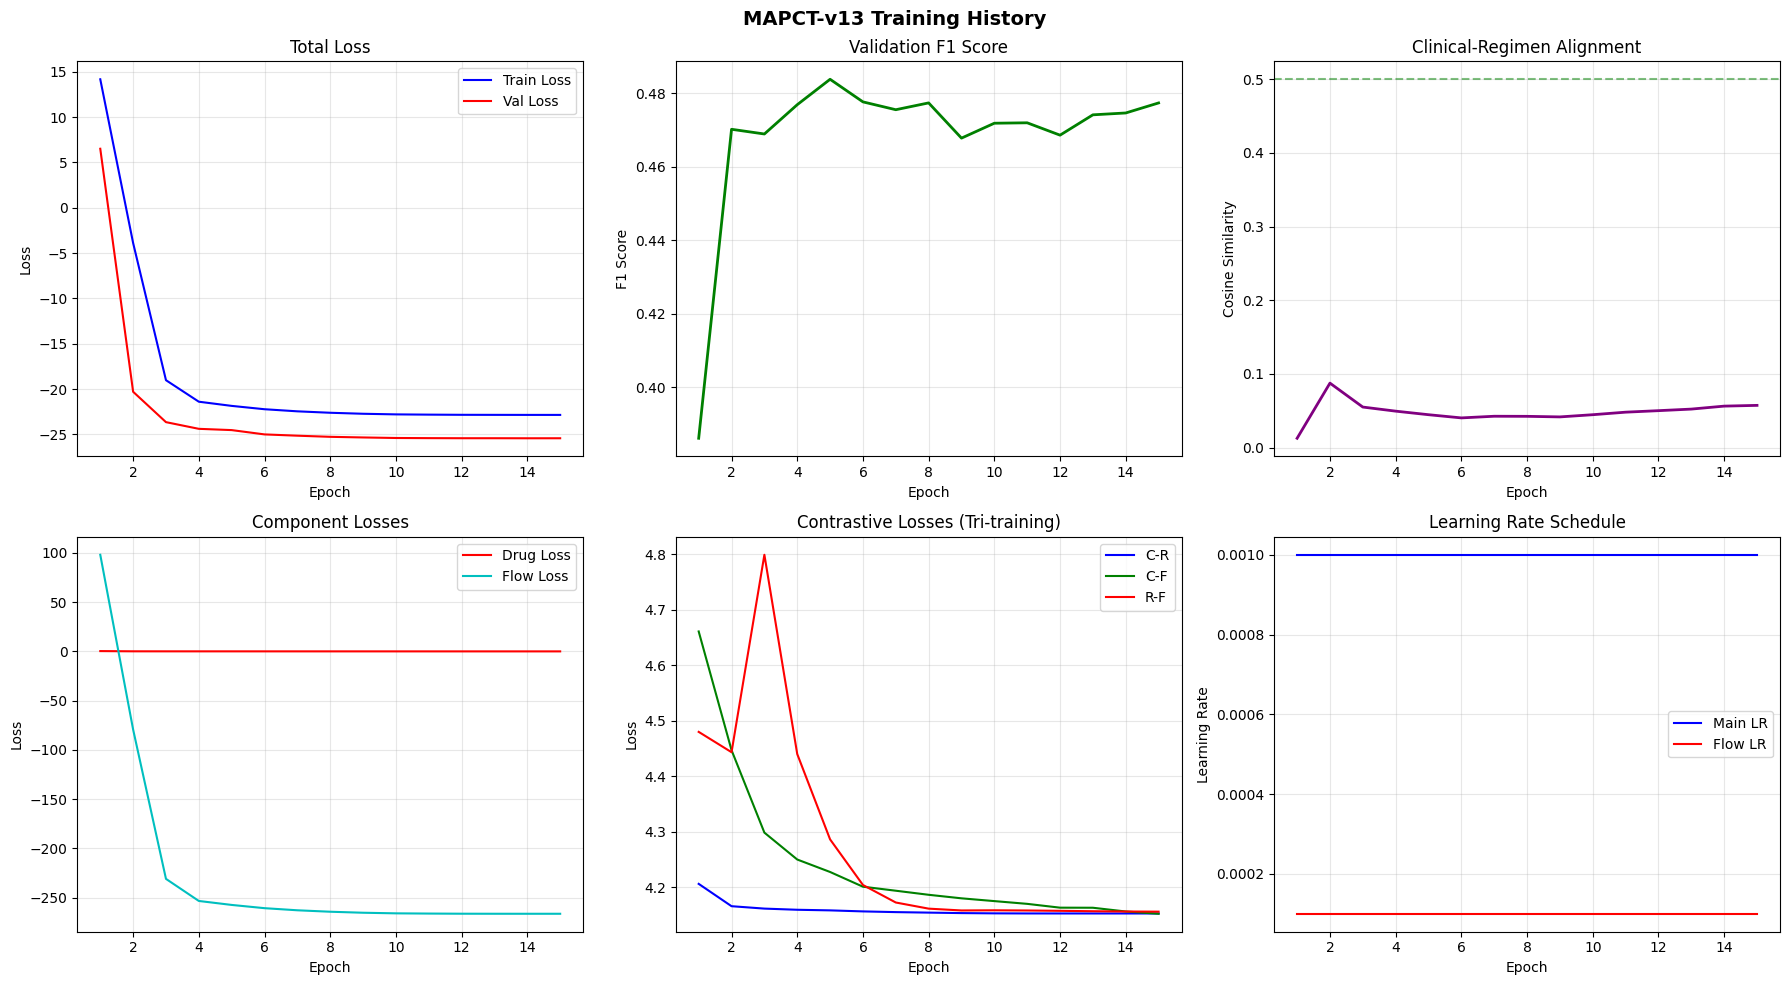

✅ Training history saved as 'v13_training_history.png'

🔗 CLINICAL-REGIMEN ALIGNMENT ANALYSIS


Computing alignment: 100%|██████████| 15/15 [00:00<00:00, 33.54it/s]


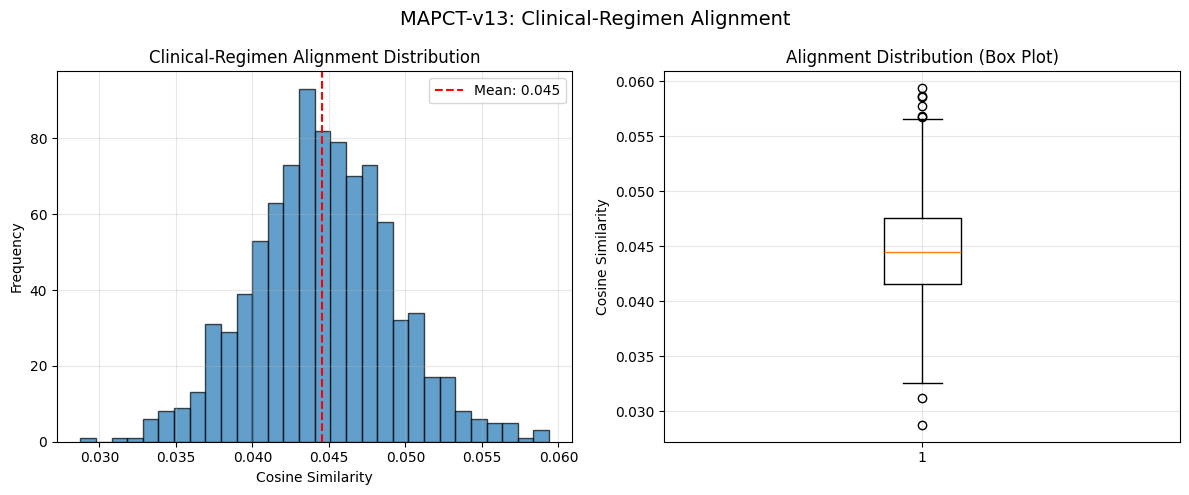


📊 Alignment Statistics:
   Mean: 0.0446
   Std:  0.0046
   Min:  0.0287
   Max:  0.0594
   Median: 0.0445

🎨 LATENT SPACE VISUALIZATION


Computing t-SNE...


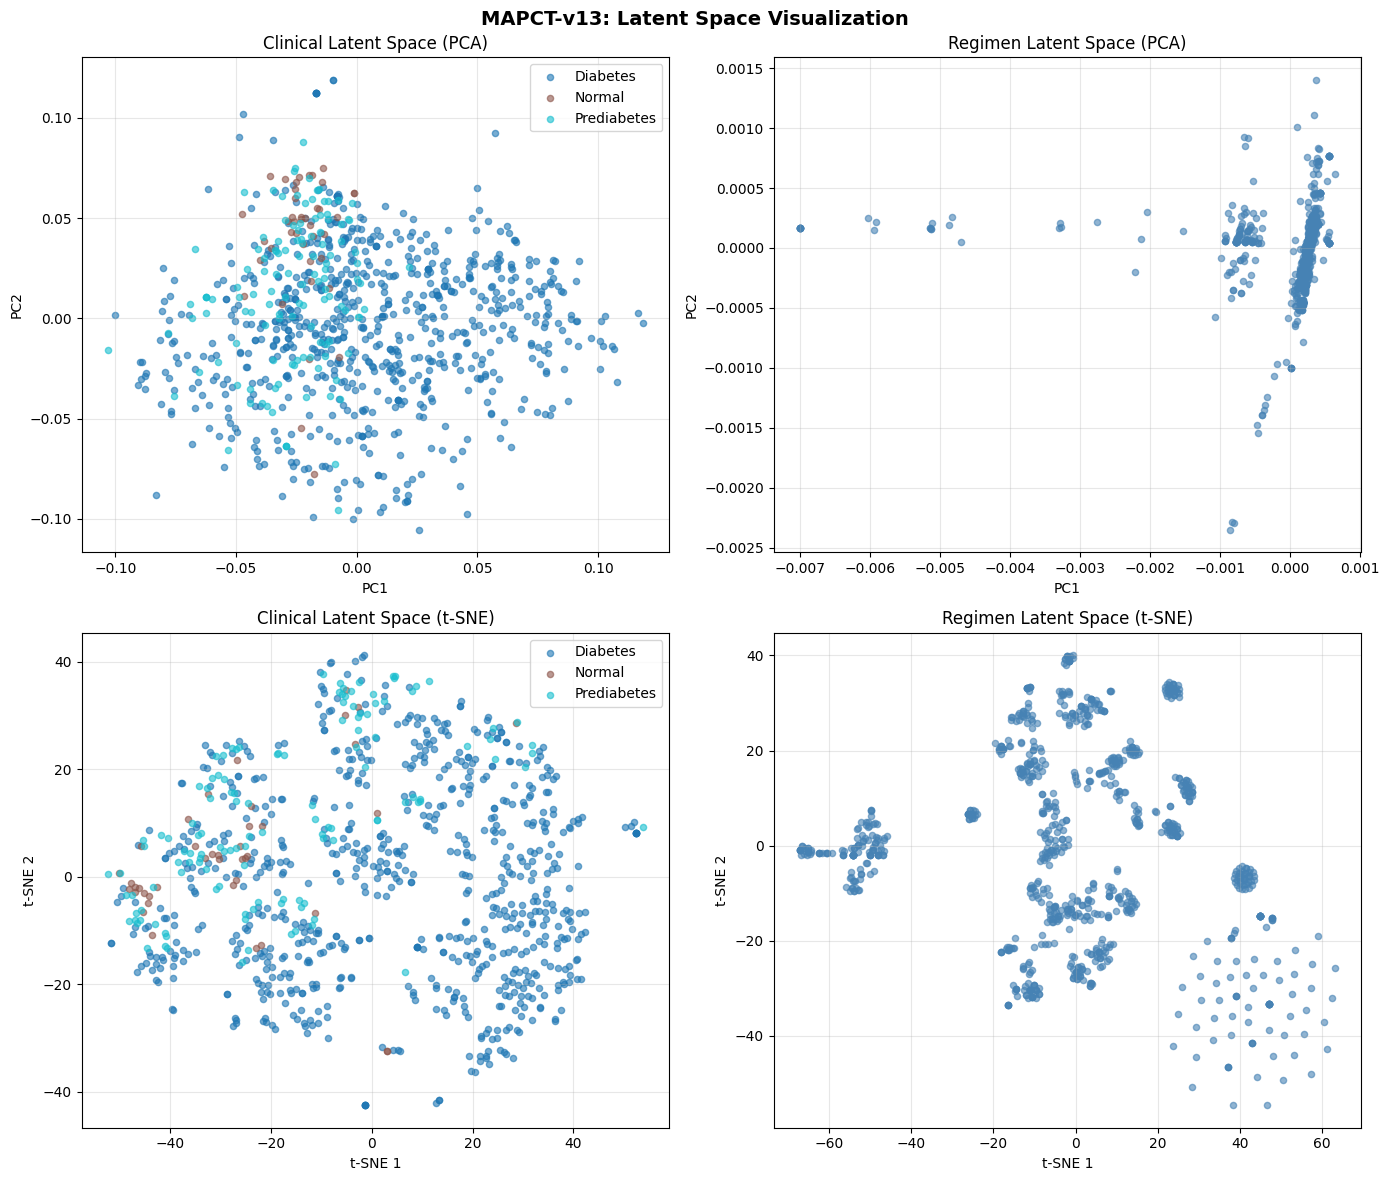

✅ Latent space plots saved as 'v13_latent_spaces.png'

🎨 UMAP LATENT SPACE VISUALIZATION (v13)


Computing UMAP for clinical space...
Computing UMAP for regimen space...


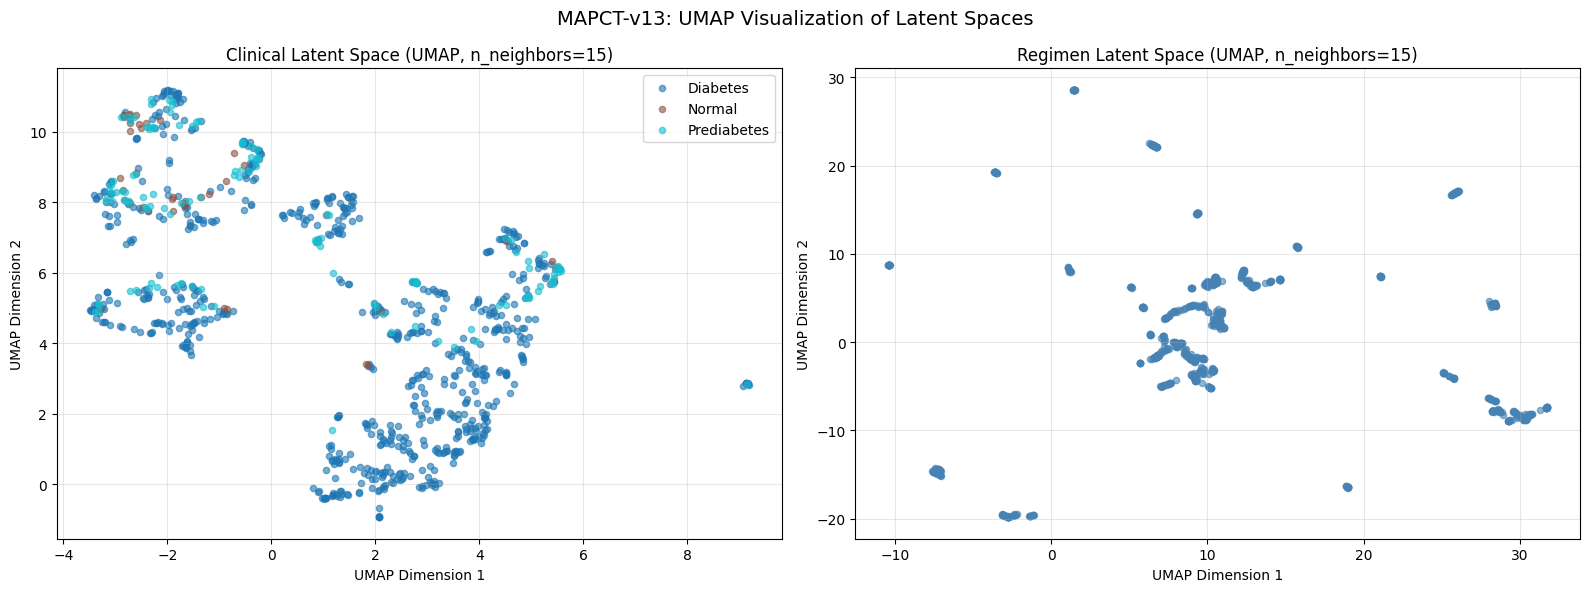

✅ UMAP plot saved as 'v13_latent_umap.png'

🔗 JOINT LATENT SPACE VISUALIZATION (Clinical vs Drug)


   Computing t-SNE on combined latents...
   Computing UMAP on combined latents...


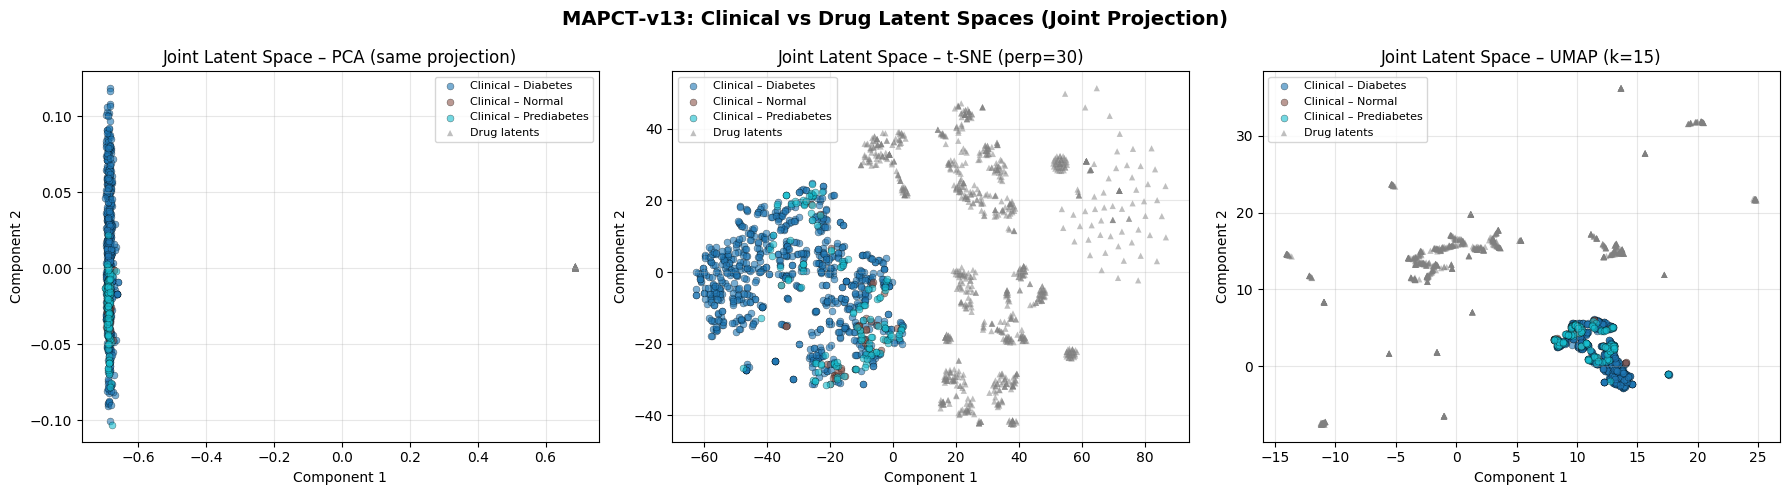

✅ Joint latent space plot saved as 'v13_joint_latent_spaces.png'

📊 COMPLETE METRICS FOR MAPCT-v13


Evaluating: 100%|██████████| 15/15 [00:01<00:00,  8.26it/s]



🎯 Drug Prediction (threshold=0.3):
   Precision: 0.5264
   Recall:    0.4581
   F1-Score:  0.4899
   Accuracy:  0.9825

🔗 Clinical–Regimen Alignment:
   Mean cosine: 0.0446 ± 0.0046

🎨 Generation Diversity:
   Mean Jaccard distance: 0.2534

✅ Metrics saved to 'mapct_v13_metrics.json'

👥 PATIENT-LEVEL ANALYSIS

PATIENT 1 (Test index: 0)

📊 CLINICAL PROFILE:
   Age: 67.0
   Sex: 1
   HbA1c: 7.7 (Diabetes)

💊 ACTUAL REGIMEN: aspirin, insulin aspart, insulin glargine, losartan, metformin

🤖 PREDICTED REGIMEN (threshold=0.3):
   • metformin                           prob=0.8199
   • atorvastatin                        prob=0.4102

🔗 CLINICAL-REGIMEN ALIGNMENT: 0.0364

PATIENT 2 (Test index: 1)

📊 CLINICAL PROFILE:
   Age: 63.00000000000001
   Sex: 0
   HbA1c: 9.6 (Diabetes)

💊 ACTUAL REGIMEN: atorvastatin, metformin

🤖 PREDICTED REGIMEN (threshold=0.3):
   • metformin                           prob=0.8007
   • losartan                            prob=0.3583
   • atorvastatin               

In [ ]:

# ============================================================
# STEP 22: MAIN EXECUTION
# ============================================================

if __name__ == "__main__":
    print("\n" + "="*80)
    print("🚀 MAPCT-v13: HYBRID FLOW + GNN + CONTRASTIVE TRI-TRAINING")
    print("="*80)

    # Initialize model
    model = MAPCTv13(
        clinical_dim=clinical_dim,
        drug_to_idx=drug_to_idx,
        drug_embeddings=drug_embeddings,
        drug_edge_index=drug_edge_index,
        clinical_df=clinic_df,
        latent_dim=128
    ).to(device)

    print(f"\n✅ Model initialized:")
    print(f"   Clinical dimension: {clinical_dim}")
    print(f"   Drug vocabulary size: {num_drugs}")
    print(f"   Drug graph edges: {drug_edge_index.shape[1]}")
    print(f"   Latent dimension: 128")
    print(f"   Flow layers: 6")
    print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Create trainer
    trainer = MAPCTv13Trainer(
        model=model,
        device=device,
        train_loader=train_loader,
        val_loader=val_loader,
        lr=1e-3,
        flow_lr=1e-4,
        lambda_drug=1.0,
        lambda_flow=0.1,
        alpha_CR=0.3,
        alpha_CF=0.3,
        alpha_RF=0.3
    )

    # Train model
    print("\n" + "="*80)
    print("🎯 STARTING TRI-TRAINING")
    print("="*80)

    history = trainer.train(epochs=50, patience=10)

    # Load best model
    model.load_state_dict(torch.load('best_mapct_v13.pt', map_location=device))
    print("\n✅ Loaded best model based on validation F1")

    # Ensure edge_index is on correct device
    model.drug_edge_index = drug_edge_index.to(device)

    # Visualizations
    print("\n" + "="*80)
    print("📊 GENERATING VISUALIZATIONS AND METRICS")
    print("="*80)

    # Training history
    visualize_training_history(history)

    # Alignment analysis
    alignments = visualize_alignment_v13(model, test_loader, device)


    # Latent space visualizations
    Z_clin, Z_reg = visualize_latent_spaces_v13(model, test_loader, test_df, device)

    # UMAP visualization (if available)
    if UMAP_AVAILABLE:
        visualize_umap_latent_spaces_v13(model, test_loader, test_df, device, n_neighbors=15)
    else:
        print("⚠️ UMAP not available - skipping UMAP visualization")

    # JOINT latent space visualization (clinical + drug together)
    visualize_joint_latent_spaces_v13(model, test_loader, test_df, device,
                                      methods=['pca', 'tsne', 'umap'],
                                      perplexity=30, n_neighbors=15)

    # Complete metrics
    metrics = compute_complete_metrics(model, test_loader, device, threshold=0.3, num_stochastic=5)

    # Save metrics
    with open('mapct_v13_metrics.json', 'w') as f:
        json.dump(metrics, f, indent=4)
    print("\n✅ Metrics saved to 'mapct_v13_metrics.json'")

    # Patient analysis
    show_patient_analysis_v13(model, test_loader, test_df, idx_to_drug, device, threshold=0.3)

    # Save final model
    torch.save(model.state_dict(), '/content/drive/MyDrive/khezri/mapct_v13_model.pt')
    print("\n✅ Final model saved to Google Drive")

    print("\n" + "="*80)
    print("✅ MAPCT-v13 COMPLETE!")
    print(f"   Best Validation F1: {max(history['val_f1']):.4f}")
    print(f"   Test F1: {metrics['f1']:.4f}")
    print(f"   Clinical-Regimen Alignment: {metrics['alignment']:.4f}")
    print(f"   Generation Diversity: {metrics['diversity']:.4f}")
    print("="*80)